In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned Zillow dataset
df = pd.read_csv("zillow_cleaned.csv")  # adjust filename if needed
df.head()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,7.0,33634931.0,-117869207.0,4506.0,261.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,4.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,10.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


In [5]:
import pandas as pd
import numpy as np

# Zillow-specific column selection
selected_cols = {
    "price": "taxvaluedollarcnt",
    "bedrooms": "bedroomcnt",
    "bathrooms": "bathroomcnt",  # backup: "calculatedbathnbr"
    "sqft": "calculatedfinishedsquarefeet",  # backup: "finishedsquarefeet12"
    "lot_size": "lotsizesquarefeet",
    "year_built": "yearbuilt"
}

# Create df_cluster
df_cluster = df[list(selected_cols.values())].copy()

# Add price_per_sqft
df_cluster["price_per_sqft"] = (
    df[selected_cols["price"]] / df[selected_cols["sqft"]]
)

# Drop missing values
df_cluster = df_cluster.dropna()

print("Final df_cluster shape:", df_cluster.shape)
df_cluster.head()

Final df_cluster shape: (64894, 7)


,taxvaluedollarcnt,bedroomcnt,bathroomcnt,calculatedfinishedsquarefeet,lotsizesquarefeet,yearbuilt,price_per_sqft
0,1023282.0,4.0,3.5,3100.0,4506.0,1998.0,330.090968
1,464000.0,2.0,1.0,1465.0,12647.0,1967.0,316.723549
2,564778.0,3.0,2.0,1243.0,8432.0,1962.0,454.366854
3,145143.0,4.0,3.0,2376.0,13038.0,1970.0,61.087121
4,119407.0,3.0,3.0,1312.0,278581.0,1964.0,91.011433


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

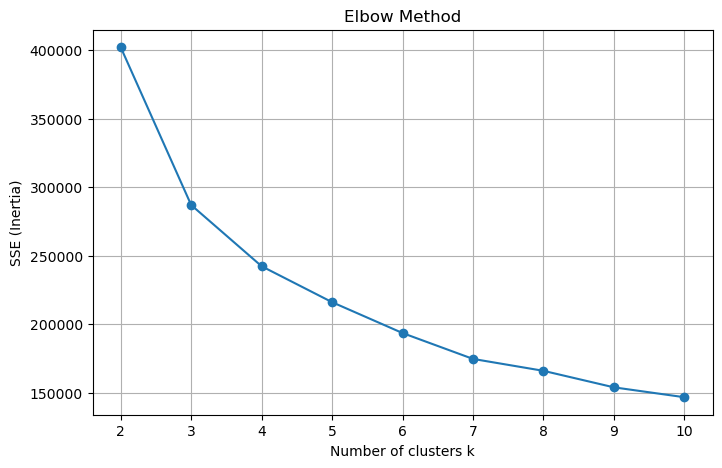

In [7]:
sse = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, sse, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

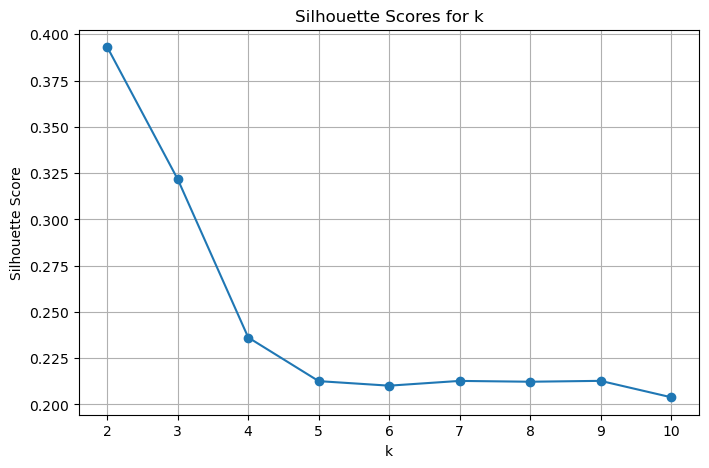

[0.39302952425990234,
 0.3216332948036314,
 0.23619716470774924,
 0.21262613430238214,
 0.2101714385657506,
 0.2127449086028443,
 0.21229992011696486,
 0.21277679503292385,
 0.20393095471300202]

In [8]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for k')
plt.grid(True)
plt.show()

sil_scores

In [9]:
best_k = sil_scores.index(max(sil_scores)) + 2

kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters
df_cluster.head()

,taxvaluedollarcnt,bedroomcnt,bathroomcnt,calculatedfinishedsquarefeet,lotsizesquarefeet,yearbuilt,price_per_sqft,cluster
0,1023282.0,4.0,3.5,3100.0,4506.0,1998.0,330.090968,1
1,464000.0,2.0,1.0,1465.0,12647.0,1967.0,316.723549,1
2,564778.0,3.0,2.0,1243.0,8432.0,1962.0,454.366854,1
3,145143.0,4.0,3.0,2376.0,13038.0,1970.0,61.087121,1
4,119407.0,3.0,3.0,1312.0,278581.0,1964.0,91.011433,0


In [10]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroids

,price,bedrooms,bathrooms,sqft,lot_size,year_built,price_per_sqft
0,307425.558723,2.189340,2.132166,1242.628447,265038.495507,1979.928107,252.536785
1,467863.090632,3.128821,2.274077,1794.646359,12876.195761,1966.485624,258.573569


In [11]:
sns.scatterplot(
    x=df_cluster['sqft'], 
    y=df_cluster['price'], 
    hue=df_cluster['cluster'], 
    palette='tab10'
)
plt.title('Clusters by Size and Price')
plt.show()

KeyError: 'sqft'